Ethan Ho
017157582
CMPE 188

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import set_option
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix

### Dataset Details

- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per $10,000
- PTRATIO - pupil-teacher ratio by town
- B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT - % lower status of the population
- MEDV - Median value of owner-occupied homes in $1000's

In [82]:
bostonData = pd.read_csv("E:/vs/school/CMPE_188/data/boston.csv")
bostonData.head(15)

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,6,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


The zn coloum seems to have some data here and there which makes the coloum over no use so I decided to drop it. The chas coloum was also suspicious being only zeros in the preview but I decided to keep it after reading that it was a boolean to express its location relative to the river. The other coloums and its data look relatively consistent just from the top few rows, thus I only removed one row (and also the extra idx column). There is also no categorical data to drop.

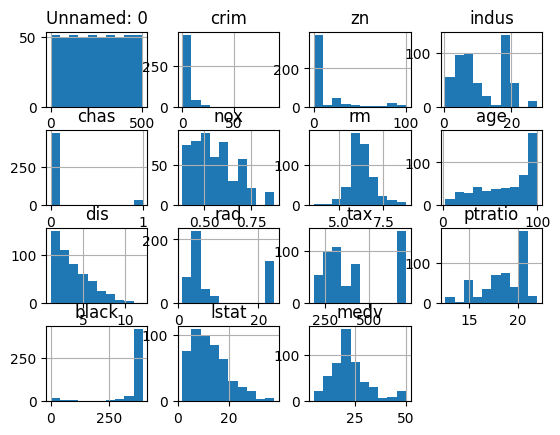

In [83]:
bostonData.hist()
plt.show()

Correction, although the zn had strange zeros I have decided that it is still data and that I should keep it. However the distribution for Chas is definently weird so I will remove that.

In [84]:
df = bostonData.drop(['chas', bostonData.columns[0]], axis=1)
print(df.shape)
df.head()

(506, 13)


,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [85]:
# Splitting the data into inputs and outputs
X1 = df.drop(['medv'], axis=1)
Y1 = df.drop(df.columns[0:12], axis=1)

In [86]:
#Standardization
scalerS = StandardScaler().fit(X1)
data_stand = pd.DataFrame(scalerS.transform(X1), columns=X1.columns)
data_stand['medv'] = Y1.values

In [87]:
# Descriptive Statistics
data_stand.describe()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02,506.000000
mean,-1.123388e-16,7.898820e-17,2.106352e-16,-1.965929e-16,-1.088282e-16,-1.474446e-16,-8.425408e-17,-1.123388e-16,0.000000,-4.212704e-16,-7.442444e-16,-3.089316e-16,22.532806
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990,1.000990e+00,1.000990e+00,1.000990e+00,9.197104
min,-4.197819e-01,-4.877224e-01,-1.557842e+00,-1.465882e+00,-3.880249e+00,-2.335437e+00,-1.267069e+00,-9.828429e-01,-1.313990,-2.707379e+00,-3.907193e+00,-1.531127e+00,5.000000
25%,-4.109696e-01,-4.877224e-01,-8.676906e-01,-9.130288e-01,-5.686303e-01,-8.374480e-01,-8.056878e-01,-6.379618e-01,-0.767576,-4.880391e-01,2.050715e-01,-7.994200e-01,17.025000
50%,-3.906665e-01,-4.877224e-01,-2.110985e-01,-1.442174e-01,-1.084655e-01,3.173816e-01,-2.793234e-01,-5.230014e-01,-0.464673,2.748590e-01,3.811865e-01,-1.812536e-01,21.200000
75%,7.396560e-03,4.877224e-02,1.015999e+00,5.986790e-01,4.827678e-01,9.067981e-01,6.623709e-01,1.661245e+00,1.530926,8.065758e-01,4.336510e-01,6.030188e-01,25.000000
max,9.933931e+00,3.804234e+00,2.422565e+00,2.732346e+00,3.555044e+00,1.117494e+00,3.960518e+00,1.661245e+00,1.798194,1.638828e+00,4.410519e-01,3.548771e+00,50.000000


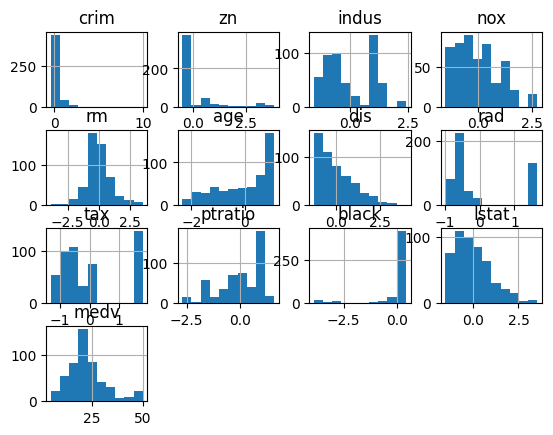

In [88]:
data_stand.hist()
plt.show()

The graphs before and after standardization look very similar 

In [89]:
#Normalization
scalerN = Normalizer().fit(X1)
data_norm = pd.DataFrame(scalerN.transform(X1), columns=X1.columns)
data_norm['medv'] = Y1.values

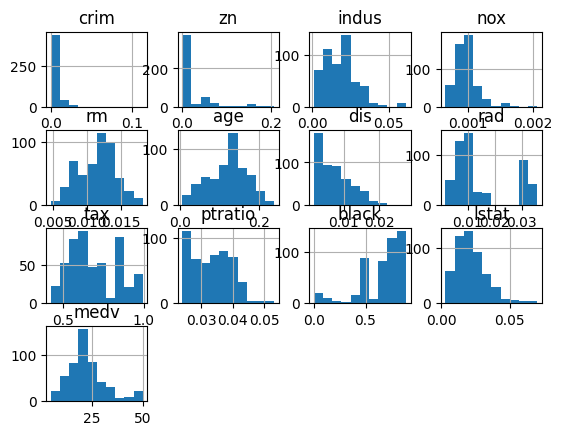

In [90]:
data_norm.hist()
plt.show()

After normalizing the data the histograms show more resemblance to a bellman curve. 

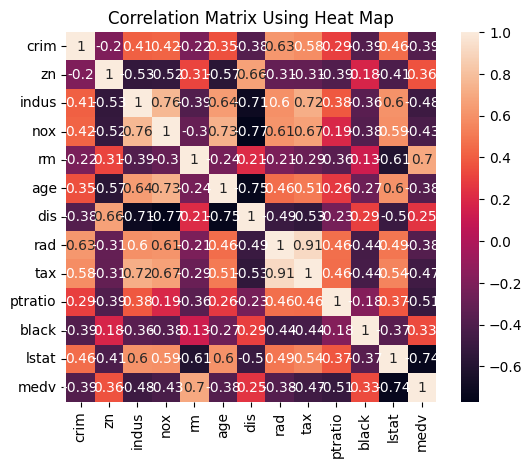

In [91]:
# Correlation Heat Map
plt.figure()
correlationMap = df.corr(method='pearson')
sns.heatmap(correlationMap, square=True, annot=True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title("Correlation Matrix Using Heat Map")
plt.show()

The data seems to vary in correlation with some columns having high negative and positive correlation 

<Figure size 640x480 with 0 Axes>

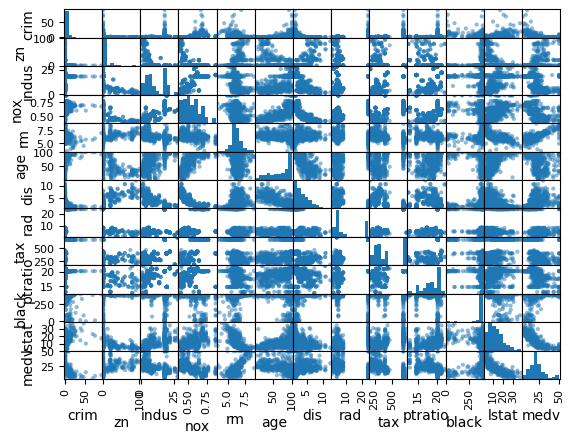

In [92]:
# Scatterplot
plt.figure()
scatter_matrix(df)
plt.show()

After taking a look at the scatterplots, I can see that most of them follow a pattern that may or may not be linear.

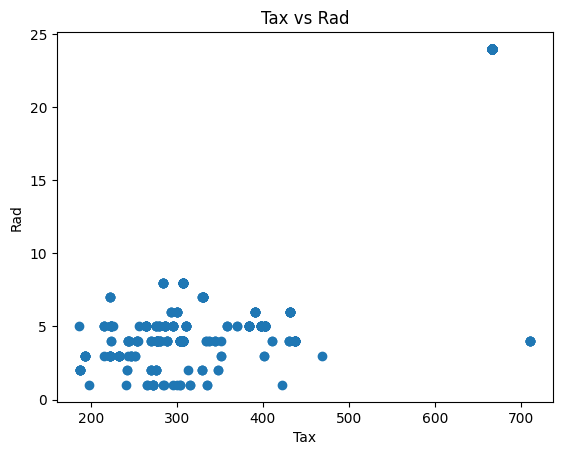

In [93]:
plt.figure()
plt.scatter(df['tax'], df['rad'])
plt.xlabel('Tax')
plt.ylabel('Rad')
plt.title('Tax vs Rad')
plt.show()

To compare with the correlation heatmap, the Tax and Rad coloumn has the highest correlation of 0.91. It essentially says that a person's property tax is linearly correlated to their accessiability to radical highways. However after looking at the scatterplot it is a little difficult to tell as the data points seem to be clustered to the bottom left corner.

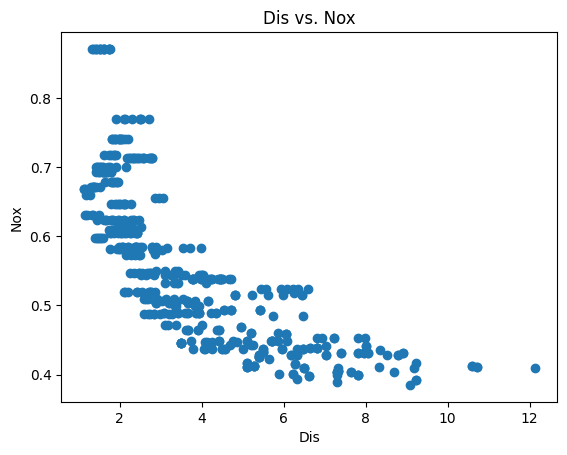

In [97]:
plt.figure()
plt.scatter(df['dis'], df['nox'])
plt.title('Dis vs. Nox')
plt.xlabel('Dis')
plt.ylabel('Nox')
plt.show()

Another, more clear example, would be the columns Dis vs. Nox as they have a negative correlation of -0.77. This scatterplot more confidently represents a negatively linear pattern that we would expect to see with our correlation calculation.

<function matplotlib.pyplot.show(close=None, block=None)>

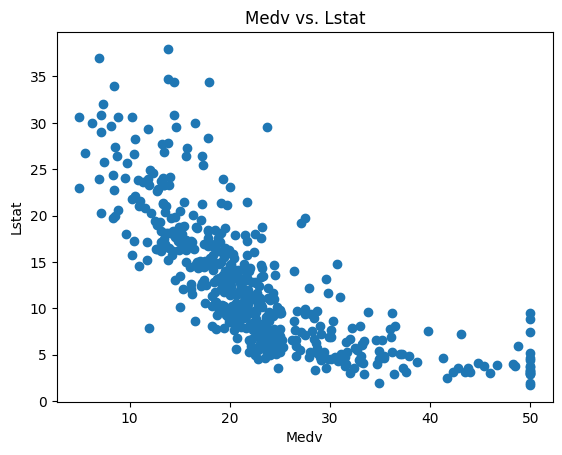

In [98]:
plt.figure()
plt.scatter(df['medv'], df['lstat'])
plt.title('Medv vs. Lstat')
plt.xlabel('Medv')
plt.ylabel('Lstat')
plt.show

Here is another notably observably negative correlation between Medv vs. Lstat.